In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import pyplot
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression  
from sklearn.neighbors import KNeighborsClassifier  
from sklearn.svm import SVC

In [2]:
import warnings
import pandas as pd
warnings.filterwarnings("ignore", category=DeprecationWarning) 
warnings.filterwarnings("ignore", category=FutureWarning) 
warnings.filterwarnings("ignore",category=UserWarning)
# to display all columns and rows:
pd.set_option('display.max_columns', None); pd.set_option('display.max_rows', None);

In [3]:
df = pd.read_csv("churn.csv")

EDA

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.shape

(10000, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
df.drop(columns=["RowNumber"],inplace=True)

In [9]:
df.describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
5%,1.557882e+07,489.000000,25.000000,1.000000,0.000000,1.000000,0.00000,0.000000,9851.818500,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
90%,1.579083e+07,778.000000,53.000000,9.000000,149244.792000,2.000000,1.00000,1.000000,179674.704000,1.000000
95%,1.580303e+07,812.000000,60.000000,9.000000,162711.669000,2.000000,1.00000,1.000000,190155.375500,1.000000


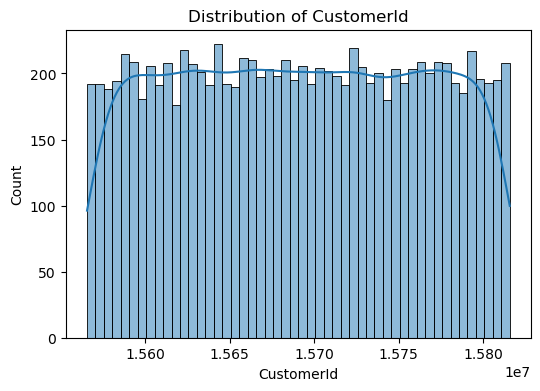

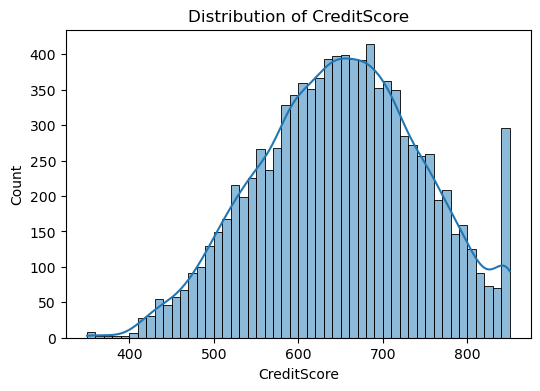

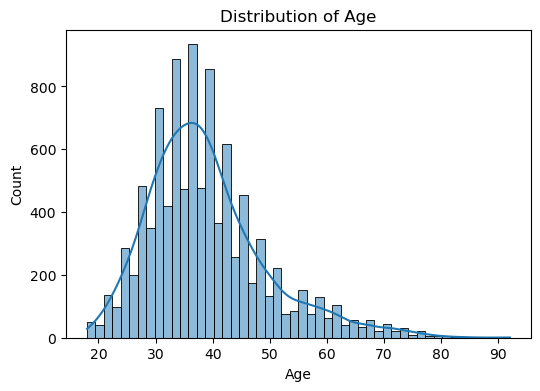

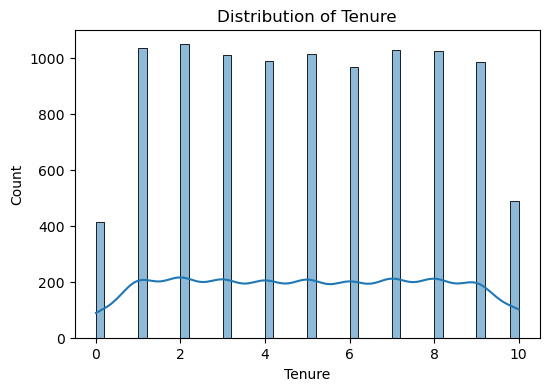

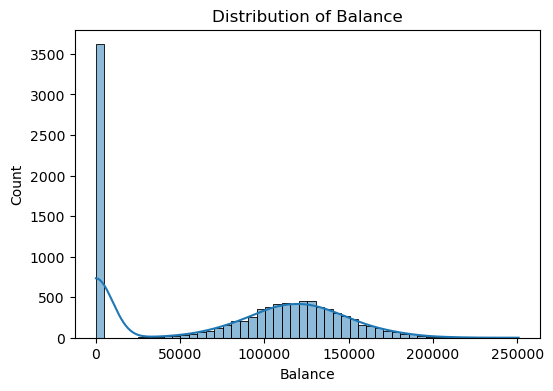

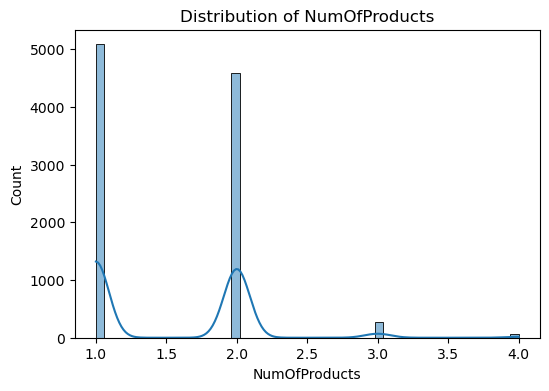

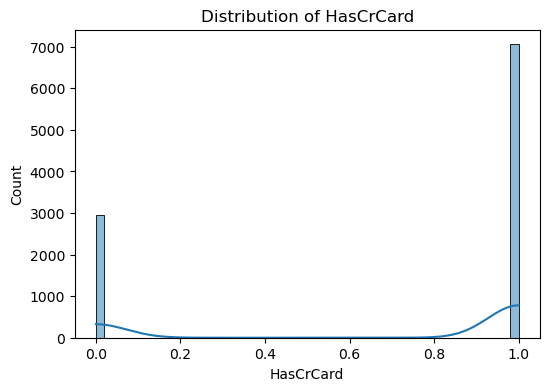

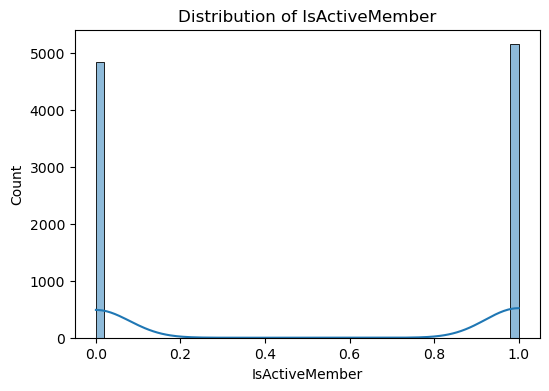

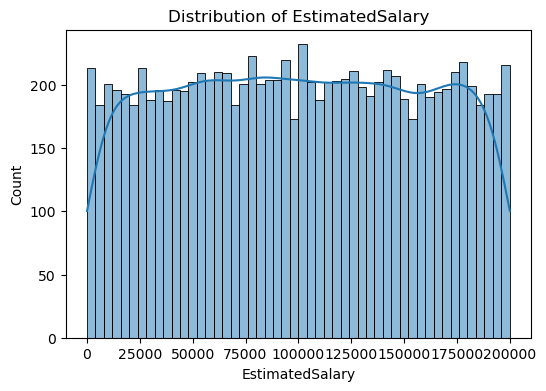

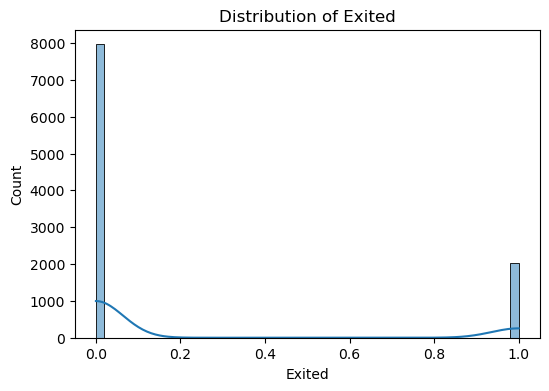

In [10]:
for col in df.select_dtypes(include="number").columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=50)
    plt.title(f"Distribution of {col}")
    plt.show()

In [11]:
#categorical_variables 
categorical_variables = [col for col in df.columns if (df[col].dtype == "0" or 
                                                       df[col].nunique() <= 11 ) and col!= "Exited"]

In [12]:
categorical_variables

['Geography',
 'Gender',
 'Tenure',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember']

What you want: Check if the column’s data type is object (text).
Correct version:

df[col].dtype == "O"
df[col].nunique() <= 11

This checks if the column has 11 or fewer unique values.

Example:

Gender: only 2 unique values → categorical.

NumOfProducts: 4 unique values → categorical.

CustomerId: thousands of unique values → not categorical.
What you want: exclude the column named "Exited".
Correct version:

col != "Exited"

1. Strict definition

Yes, you’re right:
In the pure definition, categorical variables are text/character columns like "Gender", "Country", "City".

2. Practical definition in data analysis

But in machine learning / data analysis, we often treat numeric columns with only a few unique values as categorical too.
Why?
Because their numbers don’t really represent continuous measurements, they just represent categories.

Example:

"NumOfProducts" → values {1, 2, 3, 4}

Even though it’s stored as numbers, those are just categories of product counts.

We don’t care about the "distance" between 1 and 4 like in Age or Salary.

So it’s better treated as categorical (often one-hot encoded).

3. Comparison
Column	Type in dataset	How we treat it
Gender	string	categorical
Country	string	categorical
NumOfProducts	numeric (int)	categorical (few discrete options)
Balance	numeric (float)	numerical (continuous)
Age	numeric (int)	numerical (continuous)
4. So the use of df[col].nunique() <= 11

This part is specifically there to catch numeric columns with only a few distinct values → because they act like categories.

For example:

HasCrCard (0 or 1 → categorical yes/no variable).

IsActiveMember (0 or 1 → categorical yes/no variable).

NumOfProducts (1, 2, 3, 4 → categorical options).

✅ That’s why code includes NumOfProducts in categorical variables, even though it’s numeric.

In [13]:
#Numeric varibales
numeric_variables = [
    col for col in df.columns
    if df[col].dtype != "object"
    and df[col].nunique() > 11
    and col != "CustomerId"
]
numeric_variables

['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

Exited(Dependent Variable)

In [14]:
df["Exited"].value_counts() # Frequency of classes of dependent variable

Exited
0    7963
1    2037
Name: count, dtype: int64

In [15]:
#Customers leaving the bank
churn = df.loc[df["Exited"] == 1]

In [16]:
# Customers who did not leave the bank
not_churn = df.loc[df["Exited"]==0]


Categorical Variables

In [17]:
# Frequency of not_churn group according to Tenure
not_churn["Tenure"].value_counts().sort_values()

Tenure
0     318
10    389
9     771
6     771
4     786
3     796
5     803
1     803
8     828
2     847
7     851
Name: count, dtype: int64

# 🔎 Key insights from your table:

Tenure = 0 → 318 customers
Very few customers who stayed had a tenure of 0 (basically, new customers).
This makes sense: most customers who are brand new don’t yet fall into the “not churned” group.

Tenure = 10 → 389 customers
Few customers at max tenure (10 years). Not uncommon — not many people have been with the bank for that long.

Tenure = 6, 9 → 771 customers each
Middle tenures also exist but are less frequent compared to others.

Tenure = 7 → 851 customers
This is the most frequent group of loyal customers.

Other tenures (1–8)
All have counts between 796–847, which is relatively balanced.

✅ Interpretation

Customers with very low tenure (0 years) are the least represented in the not-churn group → meaning new customers are more likely to churn.

Customers with 7 years tenure are the most common among those who did not churn → suggesting that staying longer increases loyalty.

The distribution is fairly even across 1–9 years, but both extremes (0 years and 10 years) show fewer loyal customers.

💡 Business insight

Onboarding / first-year experience is critical → many new customers leave early.

Long-term customers (7+ years) are the backbone of retention → they’re much less likely to churn.

The bank could focus retention efforts on new customers (<2 years tenure) to improve loyalty.

In [18]:
# Frequency of churn group according to Tenure
churn["Tenure"].value_counts().sort_values()

Tenure
0      95
10    101
7     177
6     196
8     197
2     201
4     203
5     209
3     213
9     213
1     232
Name: count, dtype: int64

In [19]:
# Frequency of not_churn group according to NumOfProducts
not_churn["NumOfProducts"].value_counts().sort_values()

NumOfProducts
3      46
1    3675
2    4242
Name: count, dtype: int64

🔎 Interpretation

NumOfProducts = 1 → 3,675 customers
A large portion of loyal (not churned) customers only have 1 product with the bank.

NumOfProducts = 2 → 4,242 customers
An even larger portion have 2 products. This is the most common group among not churned.

NumOfProducts = 3 → only 46 customers
Very few loyal customers hold 3 products. This is a rare scenario.

✅ Insights

Customers with 1 or 2 products make up almost all of the non-churn group.
→ Suggests these customers are comfortable and stable.

Customers with 3 products are very rare among non-churners.
→ Possible reasons:

Those customers might churn more often.

Or very few customers actually take 3 products in the first place.

There are no customers with 4 products in the not-churn group (maybe in churn group instead).

💡 Business takeaway

Sweet spot: Offering 1–2 products seems to keep customers loyal.

Customers with 3+ products may be at higher churn risk or are not encouraged to stay.

The bank might investigate why customers with multiple products leave more often.

In [20]:
# Frequency of churn group according to NumOfProduct
churn["NumOfProducts"].value_counts().sort_values()

NumOfProducts
4      60
3     220
2     348
1    1409
Name: count, dtype: int64

In [21]:
# examining the HasCrCard of the not_churn group
not_churn["HasCrCard"].value_counts()

HasCrCard
1    5631
0    2332
Name: count, dtype: int64

In [22]:
# examining the HasCrCard of the churn group
churn["HasCrCard"].value_counts()

HasCrCard
1    1424
0     613
Name: count, dtype: int64

🔎 Interpretation

Among not churn (loyal customers):

5631 (≈71%) have a credit card.

2332 (≈29%) do not have a credit card.
👉 Majority of loyal customers do have a credit card.

Among churn (exited customers):

1424 (≈70%) had a credit card.

613 (≈30%) did not have a credit card.
👉 Distribution is almost the same as in the not churn group.

✅ Insight

Having a credit card (HasCrCard = 1) does not seem to significantly impact churn.

The proportion of credit card holders is almost identical in both groups (~70%).

This suggests credit card ownership is not a strong driver of churn in your dataset.

💡 Business takeaway

Since churn rates are nearly the same for customers with and without credit cards, just offering a credit card isn’t enough to retain customers.

The bank should focus on other variables (like Tenure, NumOfProducts, or Balance) which may have stronger influence on churn.

In [23]:
# examining the IsActiveMember of the not_churn group
not_churn["IsActiveMember"].value_counts()

IsActiveMember
1    4416
0    3547
Name: count, dtype: int64

In [24]:
# examining the IsActiveMember of the churn group
churn["IsActiveMember"].value_counts()

IsActiveMember
0    1302
1     735
Name: count, dtype: int64

In [25]:
# Frequency of not_churn group according to Geography
not_churn.Geography.value_counts().sort_values()

Geography
Germany    1695
Spain      2064
France     4204
Name: count, dtype: int64

In [26]:
# Frequency of churn group according to Geography
churn.Geography.value_counts().sort_values()

Geography
Spain      413
France     810
Germany    814
Name: count, dtype: int64

In [27]:
# Frequency of not_churn group according to Gender
not_churn.Gender.value_counts()

Gender
Male      4559
Female    3404
Name: count, dtype: int64

In [28]:
# Frequency of churn group according to Gender
churn.Gender.value_counts()

Gender
Female    1139
Male       898
Name: count, dtype: int64



Males
Not churn = 4559
Churn = 898
Total = 4559 + 898 = 5457

Females
Not churn = 3404
Churn = 1139
Total = 3404 + 1139 = 4543

Churn rates

Male churn rate
898 / 5457 × 100 ≈ 16.5 %
Female churn rate
1139/ 4543 × 100 ≈ 25.1 %

Interpretation

Male churn rate ≈ 16.5%

Female churn rate ≈ 25.1%

Female customers churn much more often than male customers.
This confirms the pattern we saw earlier — gender is an important churn predictor.

Business takeaway:
The bank should investigate why female customers are leaving more often. Possible areas:

Product offerings not aligned with female customer needs.

Differences in customer service experience.

Financial behavior differences (e.g., product bundling, tenure, credit score).


Numerical Variables

In [29]:
# Let's examine the credit score of the not_churn group
not_churn["CreditScore"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

count    7963.000000
mean      651.853196
std        95.653837
min       405.000000
5%        492.000000
25%       585.000000
50%       653.000000
75%       718.000000
90%       778.000000
95%       812.000000
99%       850.000000
max       850.000000
Name: CreditScore, dtype: float64

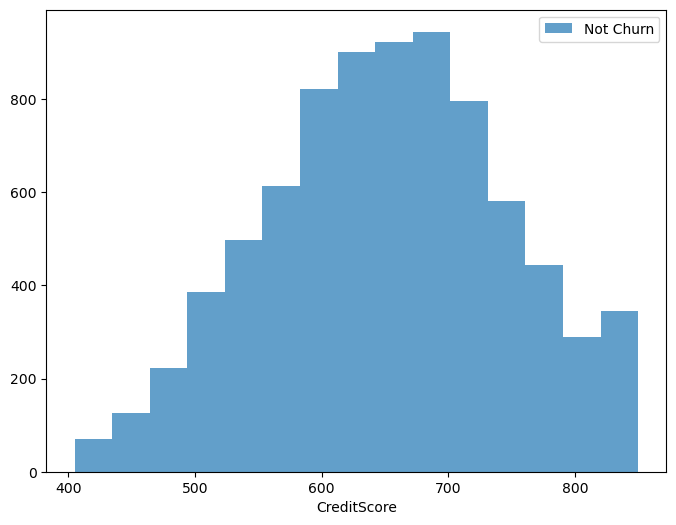

In [30]:
#distribution of credit score for not_churn
pyplot.figure(figsize=(8,6))
pyplot.xlabel('CreditScore')
pyplot.hist(not_churn["CreditScore"],bins=15,alpha=0.7,label='Not Churn')
pyplot.legend(loc='upper right')
pyplot.show()

1. Shape of the Distribution

The distribution is roughly bell-shaped (close to normal).

Most customers cluster around the 600–700 range.

Very few customers are at the lower end (~400–500) or higher end (~800+).

2. Central Tendency

The peak of the distribution is around 650–700.

This suggests that the majority of non-churning customers have average-to-above-average credit scores.

3. Spread

Scores range broadly from 400 to 850, but the majority of customers fall between 550–750.

This indicates a reasonably diverse creditworthiness among customers who stay.

4. Business Implication

Higher credit scores (650–750) are strongly associated with retention (not churning).

Customers with very low credit scores (<500) are a small group, meaning they are less represented among loyal customers.

Customers at the extreme high end (800+) are also fewer in number, but they still show lower churn.

✅ Key Insight: Customers who do not churn are typically in the middle-to-upper credit score range (600–700). This may imply that customers with very low credit scores are more likely to churn, while customers with stable or strong financial profiles are more loyal.

In [31]:
# Let's examine the credit score of the churn group
churn["CreditScore"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

count    2037.000000
mean      645.351497
std       100.321503
min       350.000000
5%        479.000000
25%       578.000000
50%       646.000000
75%       716.000000
90%       776.400000
95%       812.200000
99%       850.000000
max       850.000000
Name: CreditScore, dtype: float64

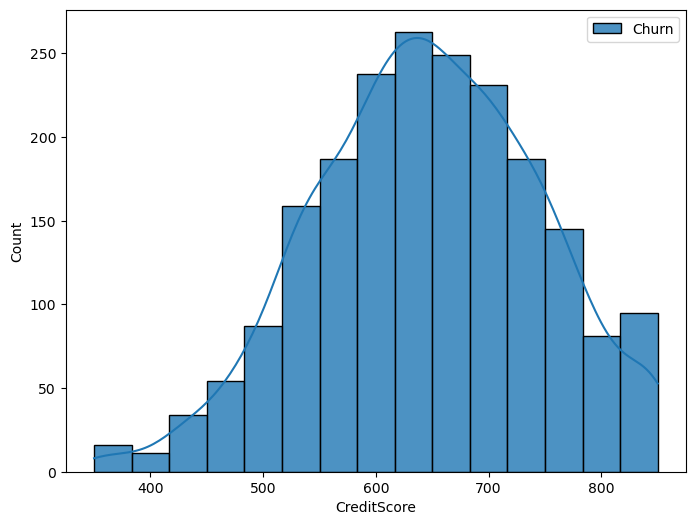

In [32]:
# distribution of the Credit Score for churn
pyplot.figure(figsize=(8,6))
pyplot.xlabel('CreditScore')
sns.histplot(churn["CreditScore"], bins=15, kde=True, alpha=0.8, label='Churn')
pyplot.legend(loc='upper right')
pyplot.show()

1. Shape of the Distribution

The distribution is roughly bell-shaped, slightly skewed to the left.

Most churned customers fall in the 550–750 range.

2. Central Tendency

The peak (mode) is around 620–650.

This suggests that churn is most common among customers with moderate credit scores, not the very low or very high ones.

3. Spread

The churn distribution spans widely from 350 up to 850, but the bulk is 500–750.

Very few churn cases occur below 450 or above 800.

4. Comparison with Non-Churn (from the earlier plot you shared)

Non-Churn Customers peaked around 650–700.

Churn Customers peak around 620–650.

This suggests churned customers tend to have slightly lower credit scores on average compared to non-churners.

5. Business Implications

Customers with average credit scores (600–650) appear more likely to churn.

Customers with very low (<500) or very high (>750) credit scores are less represented among churners, meaning they may be more stable or loyal.

Monitoring and targeting the 600–650 segment with engagement strategies (better offers, personalized services, financial products) could reduce churn.

✅ Key Insight: Churn risk is highest in the mid-credit score range (600–650), while customers with stronger or weaker credit profiles are more likely to stay.

When I said “weaker credit scores (<500) seem more likely to stay,” it doesn’t mean they’re more loyal by choice. Instead, there are a few possible business explanations:

1. Limited Alternatives

Customers with low credit scores often have fewer financial options (harder to get credit cards, loans, or switch to competing banks).

As a result, they may stick with their current bank even if they’re not fully satisfied.

2. Dependency on the Bank

Low-credit customers may rely on the bank for basic services (e.g., salary accounts, simple savings, debit cards).

They may not be the most profitable, but they are less likely to leave since other banks might reject them.

3. Risk Profile

From the bank’s side, these customers may not be aggressively targeted by competitors.

Higher-credit-score customers (650–750) are attractive to competitors, so they may receive better offers elsewhere, leading to higher churn.

✅ So the pattern isn’t that “weaker customers are happier,” but rather that they have fewer options and less incentive to churn, compared to the mid-range customers (600–650) who are both eligible for competing offers and not yet deeply loyal.

In [33]:
print("Hello")

Hello


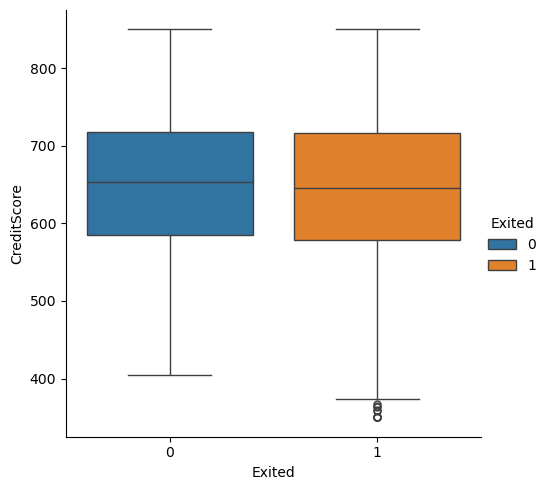

In [34]:
sns.catplot(x="Exited", y="CreditScore", data=df, kind="box",hue="Exited")
plt.show()

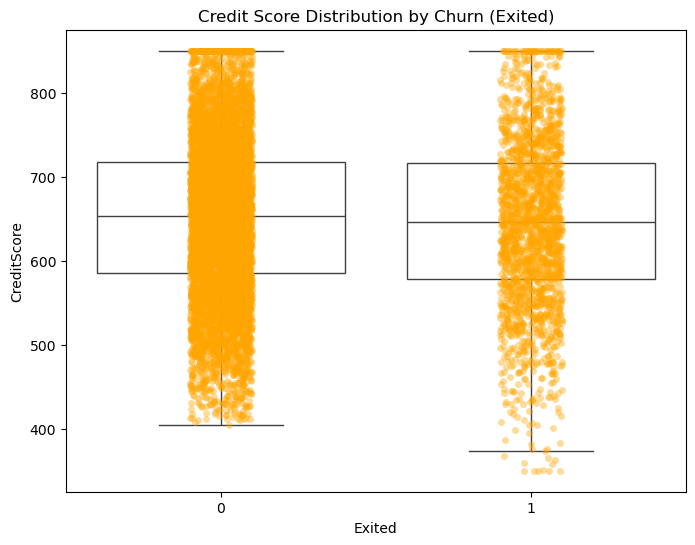

In [35]:
plt.figure(figsize=(8,6))

# Boxplot (summary statistics)
sns.boxplot(x="Exited", y="CreditScore", data=df, showcaps=True, boxprops={'facecolor':'None'}, showfliers=False)

# Swarmplot (individual points)
sns.stripplot(x="Exited", y="CreditScore", data=df, jitter=True, alpha=0.4, color="orange")

plt.title("Credit Score Distribution by Churn (Exited)")
plt.show()

If your goal is to compare churn vs non-churn statistically, the boxplot is more informative.
If you want to see data spread and density, the strip/swarm plot adds context.

1. Central Tendency (Median)

Both Exited=0 (Not Churn) and Exited=1 (Churn) have very similar median CreditScores (~650).

This suggests CreditScore alone is not a strong separator between churned and retained customers.

🔹 2. Spread (IQR & Range)

Both groups have similar interquartile ranges (middle 50% of customers between ~580 and ~710).

The overall spread goes from ~400 to ~850 for both groups.

So churners and non-churners cover roughly the same credit score range.

🔹 3. Outliers

In the churned group (Exited=1), there are slightly more customers with very low credit scores (<400).

This hints that extremely low-credit customers may be somewhat more prone to churn.

🔹 4. Distribution Overlap

The heavy overlap between the two groups means CreditScore alone does not explain churn well.

Customers across both churn and non-churn categories mostly sit in the same 600–700 range.

✅ Key Insights

CreditScore is not a strong differentiator between churners and non-churners (heavily overlapping distributions).

Customers with extremely low scores (<400) are slightly more represented among churners.

The mid-range customers (600–700) dominate both groups, so churn must be influenced by other variables (e.g., age, tenure, products held, geography, or balance).

Swarm Plot

In a swarm plot, each dot = one observation.

The dots are jittered sideways so they don’t overlap, meaning where the dots are stacked more tightly, you can visually see higher density.

Color (hue) can be used to separate categories (e.g., churn vs not churn).

In [36]:
# examining the age of the not_churn group
not_churn["Age"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

count    7963.000000
mean       37.408389
std        10.125363
min        18.000000
5%         24.000000
25%        31.000000
50%        36.000000
75%        41.000000
90%        49.000000
95%        59.000000
99%        73.000000
max        92.000000
Name: Age, dtype: float64

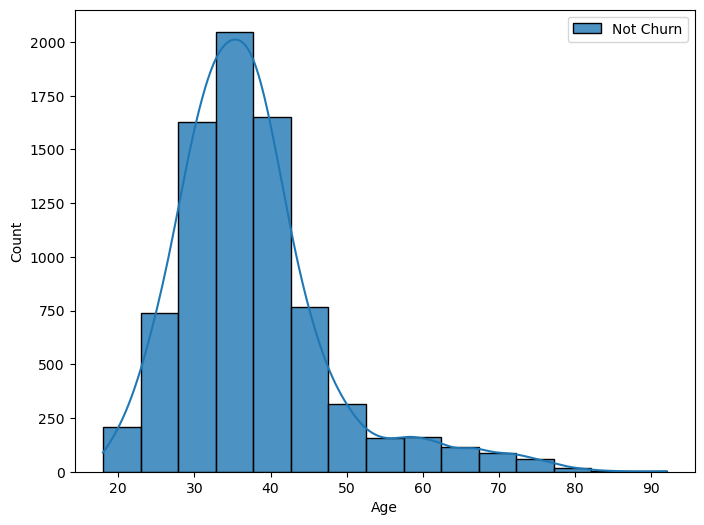

In [37]:
# distribution of the Age for not_churn
pyplot.figure(figsize=(8,6))
pyplot.xlabel('Age')
#pyplot.hist(not_churn["Age"],bins=15, alpha=0.7, label='Not Churn')
sns.histplot(not_churn["Age"], bins=15, kde=True, alpha=0.8, label='Not Churn')
pyplot.legend(loc='upper right')
pyplot.show()

In [38]:
# examine the age of the churn group
churn["Age"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

count    2037.000000
mean       44.837997
std         9.761562
min        18.000000
5%         29.000000
25%        38.000000
50%        45.000000
75%        51.000000
90%        58.000000
95%        61.000000
99%        68.000000
max        84.000000
Name: Age, dtype: float64

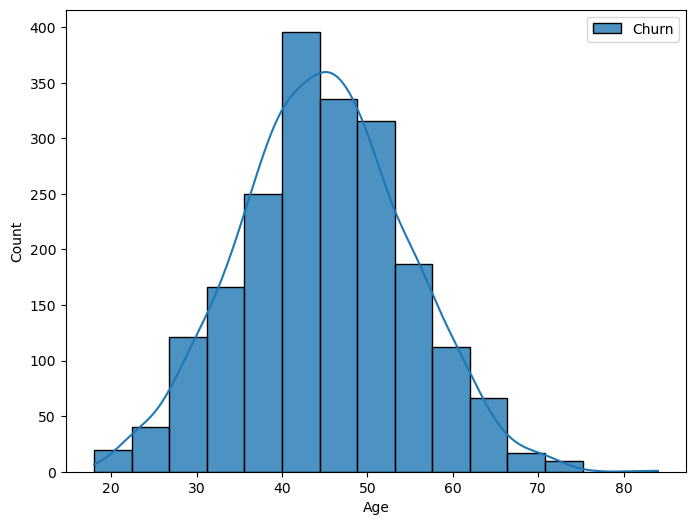

In [39]:
# distribution of the Age for not_churn
pyplot.figure(figsize=(8,6))
pyplot.xlabel('Age')
#pyplot.hist(churn["Age"],bins=15, alpha=0.7, label='Churn')
sns.histplot(churn["Age"], bins=15, kde=True, alpha=0.8, label='Churn')
pyplot.legend(loc='upper right')
pyplot.show()

1. Non-Churn Customers (Top Plot)

Shape:

Unimodal (one clear peak).

Peak at ~30–35.

Right-skewed (long tail stretching toward older ages).

Type: Positively skewed distribution.

🔹 2. Churn Customers (Bottom Plot)

Shape:

Also unimodal.

Peak at ~45–50.

Distribution is more symmetric than non-churn, but still with a slight right skew.

Type: Approximately normal-like (bell-shaped), but slightly right-skewed.

🔹 3. Comparison

Non-churn: Younger, right-skewed → lots of young customers, fewer older ones.

Churn: Older, near-normal → concentrated in middle age, less extreme skew.

✅ Summary:

Non-churn age distribution: Right-skewed (positively skewed).

Churn age distribution: Close to normal (bell-shaped), with a slight right skew.

In [40]:
from scipy.stats import skew , kurtosis
not_churn_ages = df[df["Exited"]==0]["Age"]
churn_ages = df[df["Exited"]==1]["Age"]
results = pd.DataFrame({"Group":["Not churn","Churn"],"Skewness":[skew(not_churn_ages),skew(churn_ages)],
                        "Kurtosis":[kurtosis(not_churn_ages),kurtosis(churn_ages)]})

results
                        

,Group,Skewness,Kurtosis
0,Not churn,1.377439,2.847709
1,Churn,0.077920,-0.125179


🔹 1. Not Churn (Skewness = 1.38, Kurtosis = 2.85)

Skewness (1.38 > 0):
Strong right skew → most non-churners are younger, with a long tail of older customers.

Kurtosis (2.85 > 0):
Leptokurtic → distribution is peaked and heavy-tailed compared to a normal bell curve.
This means a high concentration around younger ages (20s–30s), but also some extreme older values.

👉 Interpretation: Non-churners are mostly young (20s–30s), with a few older customers stretching the tail.

🔹 2. Churn (Skewness = 0.08, Kurtosis = -0.12)

Skewness (~0):
Almost symmetric → churner ages are centered around the middle (40s–50s).

Kurtosis (~0):
Mesokurtic → shape is close to a normal distribution, neither too peaked nor too flat.

👉 Interpretation: Churners are mostly middle-aged, with an age spread that resembles a normal bell curve.

🔹 3. Comparison

Non-churners: Younger, right-skewed, highly peaked (age concentration in 20s–30s).

Churners: Middle-aged, nearly symmetric, more evenly spread.

✅ Key Insight:

Age is a strong churn driver. Younger customers are more likely to stay (loyal/non-churn), while churn risk rises sharply among middle-aged customers (40–50s).

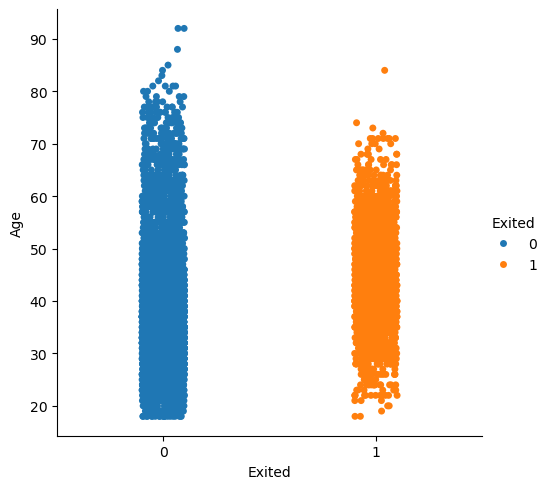

In [41]:
sns.catplot(x="Exited", y="Age", data = df,hue="Exited")

In [42]:
# examining the Balance of the not_churn group
not_churn["Balance"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

count      7963.000000
mean      72745.296779
std       62848.040701
min           0.000000
5%            0.000000
25%           0.000000
50%       92072.680000
75%      126410.280000
90%      148730.298000
95%      161592.595000
99%      183753.906200
max      221532.800000
Name: Balance, dtype: float64

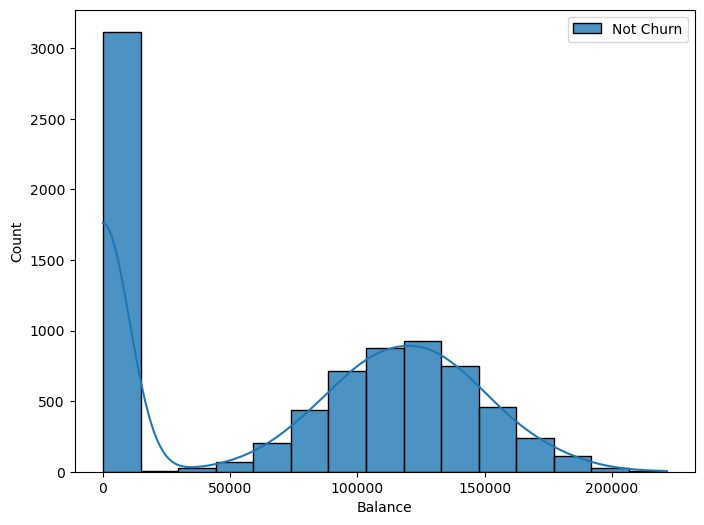

In [43]:
# distribution of the Balance for not_churn
pyplot.figure(figsize=(8,6))
pyplot.xlabel('Balance')
#pyplot.hist(not_churn["Balance"],bins=15, alpha=0.7, label='Not Churn')
sns.histplot(not_churn["Balance"], bins=15, kde=True, alpha=0.8, label='Not Churn')
pyplot.legend(loc='upper right')
pyplot.show()

Insights from the Plot:

Variable Plotted:

X-axis → Balance

Y-axis → Count

Label → Not Churn (so this plot is specifically for customers who did not churn).

Distribution Shape:

There is a very high spike at balance = 0, meaning a large number of customers (over 3000) in the dataset maintain zero balance.

Beyond zero, the distribution is roughly bell-shaped (like a normal distribution), centered around 100,000 – 120,000 balance.

The right tail extends up to 200,000+, but the frequency gradually decreases.

Interpretation:

The population of non-churned customers has two distinct groups:

A large group with zero balance (probably inactive accounts or customers who use their accounts differently).

Another group with balances around 100,000–120,000 following a normal-like distribution.

The two peaks suggest a bimodal distribution (spike at 0 and bell-shaped peak around 120k).

Business Insight:

Many loyal (non-churning) customers don’t maintain a balance in their accounts — this might imply they use the bank only for transactional purposes.

Customers with higher balances (~100k) are also not churning, suggesting financially engaged customers are retained well.

✅ Summary:
The balance distribution of non-churned customers is highly skewed due to a large mass at zero, but apart from that, it follows a normal-like distribution centered around 100k–120k. This indicates two distinct customer segments: (1) zero-balance but loyal users, and (2) higher-balance and engaged users.

In [44]:
# examining the Balance of the churn group
churn["Balance"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

count      2037.000000
mean      91108.539337
std       58360.794816
min           0.000000
5%            0.000000
25%       38340.020000
50%      109349.290000
75%      131433.330000
90%      152080.618000
95%      167698.240000
99%      197355.288400
max      250898.090000
Name: Balance, dtype: float64

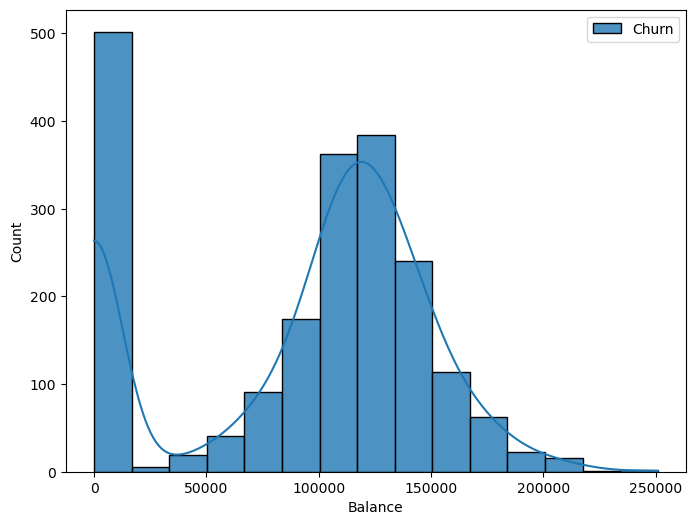

In [45]:
# distribution of the Balance for churn
pyplot.figure(figsize=(8,6))
pyplot.xlabel('Balance')
#pyplot.hist(churn["Balance"],bins=15, alpha=0.7, label='Churn')
sns.histplot(churn["Balance"], bins=15, kde=True, alpha=0.8, label='Churn')
pyplot.legend(loc='upper right')
pyplot.show()

Insights from the Churn Distribution:

Shape:

Similar to the non-churn distribution, there are two peaks:

A large spike at balance = 0 (around 500 customers).

A bell-shaped distribution centered around 110k–130k balance.

Comparison with Non-Churn:

Zero balance customers:

Much fewer in churn group (~500) compared to non-churn group (>3000).

Suggests that zero-balance customers are less likely to churn.

High balance customers (~100k–150k):

The churn distribution has a strong peak here, almost similar to non-churn, meaning customers with substantial balances are also at risk of churn.

Spread:

Both groups spread similarly up to 200k+, but churn distribution is relatively more concentrated around 100k–130k.

Business Insight:

Key churn risk lies in customers with high balances (100k–150k).
These are valuable customers for the bank, so churn here is more damaging.

Zero-balance customers are mostly loyal (not churning). This could mean they either rely on the bank for transactions (not savings) or have other reasons to stay.

The overlap in balance distribution between churn and non-churn customers suggests that balance alone is not a strong churn predictor, but combined with other features (like product usage, tenure, or activity), it can highlight risk.

✅ Summary:

Non-churners: Mostly zero-balance OR spread around 100k–120k.

Churners: Fewer zero-balance customers, but a big concentration around 100k–130k.

Key risk segment: High-balance customers (~100k–150k), who are more prone to churn than expected.

# Distribution

Distribution
Distribution of Not Churn Customers (first chart):

Bimodal distribution:

A very sharp peak at 0 balance.

A second, bell-shaped peak centered around 100k–120k.

Apart from the spike at 0, the rest of the data roughly follows a normal distribution.

The overall distribution is right-skewed (because of the tail extending toward 200k+).

📊 Distribution of Churn Customers (second chart):

Also bimodal:

First peak at 0 balance, smaller than in non-churn.

Second peak around 110k–130k.

The main bulk of the churn customers fall between 80k–160k, showing a strong concentration there.

Distribution is also right-skewed, but more concentrated in the middle compared to non-churn.

🔎 Distribution Comparison:

Both groups are bimodal → spike at 0 and a normal-like peak near 100k–130k.

Non-churners: Heavily dominated by zero-balance customers.

Churners: More evenly spread, with the majority around the central balance values (100k–130k).

Both distributions have long right tails, meaning a few customers maintain very high balances.

✅ In statistical terms:

Both churn and non-churn distributions are mixtures:

A point mass at zero (many accounts with no balance).

A continuous normal-like distribution around ~120k with right skew.

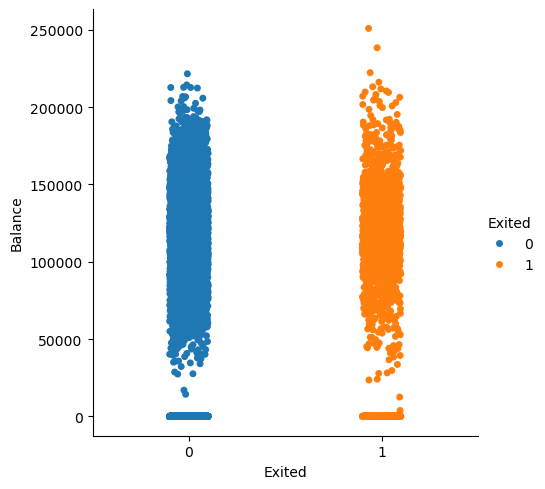

In [46]:
sns.catplot(x='Exited',y='Balance',data =df,hue='Exited')

## Observations

Zero Balance Customers:

Present in both churned (orange) and non-churned (blue) groups.

But, visually, non-churners dominate the zero-balance segment.

This suggests that customers with zero balances are more likely to stay with the bank.

Positive Balance Customers:

Both groups are spread almost identically between ~50,000 to 200,000+.

But churners (orange) are more concentrated in the 100k–150k balance range compared to non-churners.

Indicates that even financially engaged customers with higher balances are at churn risk.

Upper Range (>200k):

Both churners and non-churners exist in this range, but no clear distinction.

Suggests extreme balance customers are few and don’t exhibit a strong pattern.

🧠 Insights:

Zero Balance = Loyal: Customers with no balances are less likely to churn (probably using the bank for transactions or other services).

High Balance = At Risk: Customers with significant balances (100k–150k) have a higher chance of churn. This is counterintuitive, since high balances usually indicate strong engagement. The bank may be failing to meet expectations of this segment.

Balance Alone Not Enough: Since distributions overlap heavily, balance is not a standalone churn predictor. It must be combined with other variables (e.g., tenure, number of products, credit score, geography).

✅ Summary:

Non-churners dominate at zero balance.

Churners cluster more around mid-to-high balances (~100k–150k).

Balance is an important feature but not decisive on its own — it highlights two different churn dynamics: inactive customers stay, while valuable high-balance customers may leave.

In [47]:
# examining the EstimatedSalary of the not_churn group
not_churn["EstimatedSalary"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

count      7963.000000
mean      99738.391772
std       57405.586966
min          90.070000
5%         9773.542000
25%       50783.490000
50%       99645.040000
75%      148609.955000
90%      179453.212000
95%      190107.557000
99%      198131.465200
max      199992.480000
Name: EstimatedSalary, dtype: float64

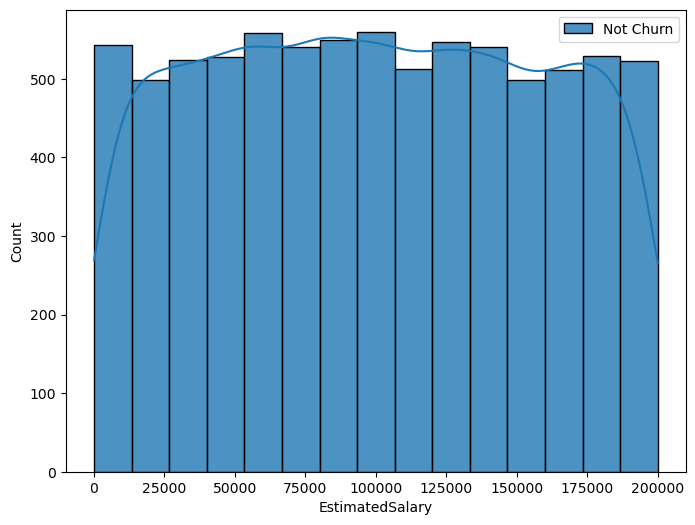

In [48]:
# distribution of the Balance for churn
pyplot.figure(figsize=(8,6))
pyplot.xlabel('EstimatedSalary')
#pyplot.hist(not_churn["EstimatedSalary"],bins=15, alpha=0.7, label='Not Churn')
sns.histplot(not_churn["EstimatedSalary"], bins=15, kde=True, alpha=0.8, label='Not Churn')
pyplot.legend(loc='upper right')
pyplot.show()

# Insights

Distribution Shape:

The distribution looks very uniform.

Customers are spread almost evenly across the entire salary range (0 to 200k).

No significant peaks or skewness — unlike balance, which had strong spikes.

Customer Spread:

Non-churn customers exist equally in all salary brackets.

This suggests that salary doesn’t strongly influence whether a customer stays.

Comparison with Balance (previous plots):

Balance showed strong bimodal patterns (lots of zero-balance and mid-to-high balance groups).

EstimatedSalary, however, is flat and evenly distributed → not a differentiating feature for churn by itself.

📊 About the Distribution:

Type: Approximately uniform distribution (all intervals are equally likely).

Range: From ~0 to ~200k.

No skewness (unlike balance, which was right-skewed).

✅ Summary:

The EstimatedSalary distribution for non-churn customers is uniform → salaries are evenly distributed across all ranges.

Salary alone does not explain churn or retention, since all salary groups are equally represented.

It likely needs to be combined with other features (e.g., balance, tenure, geography) to extract meaningful patterns.

In [49]:
# examining the EstimatedSalary of the churn group
churn["EstimatedSalary"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

count      2037.000000
mean     101465.677531
std       57912.418071
min          11.580000
5%        10030.760000
25%       51907.720000
50%      102460.840000
75%      152422.910000
90%      180169.390000
95%      190328.982000
99%      197717.297600
max      199808.100000
Name: EstimatedSalary, dtype: float64

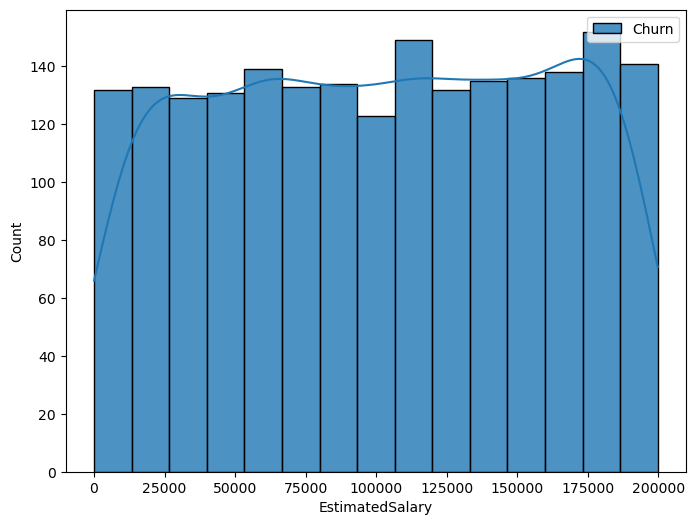

In [50]:
# distribution of the Balance for churn
pyplot.figure(figsize=(8,6))
pyplot.xlabel('EstimatedSalary')
#pyplot.hist(not_churn["EstimatedSalary"],bins=15, alpha=0.7, label='Not Churn')
sns.histplot(churn["EstimatedSalary"], bins=15, kde=True, alpha=0.8, label='Churn')
pyplot.legend(loc='upper right')
pyplot.show()

The distribution of **EstimatedSalary for churned customers** appears nearly **uniform**, similar to non-churn customers. Salaries are spread evenly across the full range (0–200k) with no significant peaks or skewness. This indicates that **salary is not a strong differentiator** for churn behavior—customers exit at similar rates regardless of income level. Unlike balance, which showed distinct patterns, estimated salary seems relatively neutral, suggesting it has **low predictive power** when used alone and should be analyzed with other features.


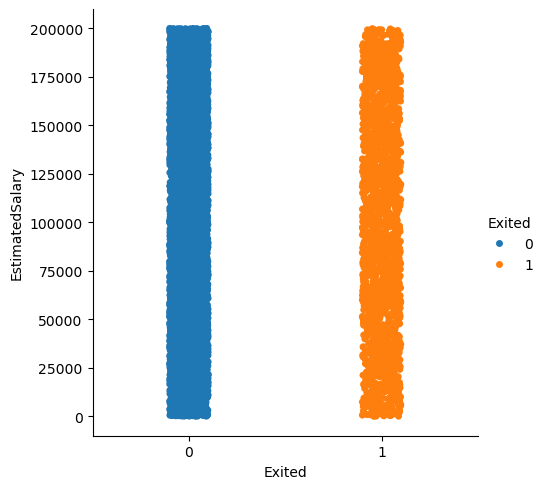

In [51]:
sns.catplot(x = "Exited", y = "EstimatedSalary", data = df,hue = "Exited")

# Correlation Matrix

df.corr()

Computes the correlation matrix of the dataframe df.

Each entry is the Pearson correlation coefficient between two variables.

.nlargest(k, 'Exited')

From the correlation matrix, it picks the top k features that have the highest correlation with the column Exited (either positive or less negative).

Here, k = 10, so it selects the 10 most correlated variables with Exited.

['Exited'].index

This extracts the index labels (column names) of those top 10 variables.

So, cols becomes a list of the 10 features most correlated with Exited.

✅ In summary:

cols contains the 10 variables most correlated with churn (Exited). These are then used to create a smaller correlation matrix (cm) and plotted in the heatmap, helping visualize relationships between the most relevant features for churn prediction.

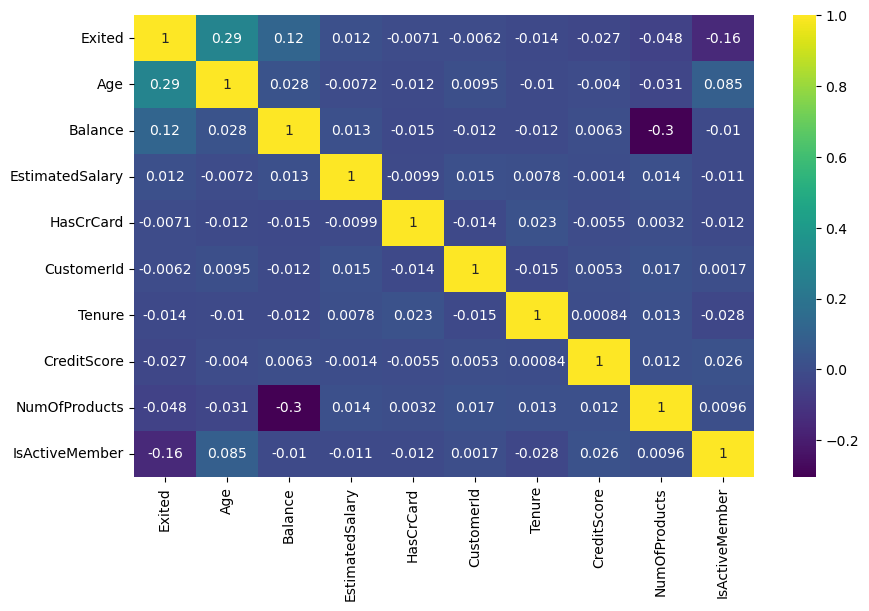

In [52]:
k = 10 #number of variables for heatmap 
# Keep only numeric columns for correlation
corr_matrix = df.select_dtypes(include=['number']).corr()
cols = corr_matrix.corr().nlargest(k, 'Exited')['Exited'].index
cm = corr_matrix.loc[cols, cols]
plt.figure(figsize=(10,6))

sns.heatmap(cm, annot=True, cmap='viridis')
plt.show()



# Data Preprocessing

In [53]:
# Missing obervation
df.isnull().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

# Outliers

In [54]:
def outlier_thresholds(df,variable,low_quartile = 0.05,uper_quartile=0.95):
    Q1 = df[variable].quantile(low_quartile)
    Q3 = df[variable].quantile(uper_quartile)
    IQR = Q3 - Q1
    up_limit = Q3 + 1.5*IQR
    low_limit = Q1 - 1.5*IQR
    return low_limit,up_limit

In [55]:
# Are there any outliers in the variables
def has_outliers(dataframe, numeric_columns, plot=False):
   # variable_names = []
    for col in numeric_columns:
        low_limit, up_limit = outlier_thresholds(dataframe, col)
        if dataframe[(dataframe[col] > up_limit) | (dataframe[col] < low_limit)].any(axis=None):
            number_of_outliers = dataframe[(dataframe[col] > up_limit) | (dataframe[col] < low_limit)].shape[0]
            print(col, " : ", number_of_outliers, "outliers")
            #variable_names.append(col)
            if plot:
                sns.boxplot(x=dataframe[col])
                plt.show()
    #return variable_names

In [56]:
# There is no outlier
for var in numeric_variables:
    print(var, "has " , has_outliers(df, [var]),  "Outliers")

CreditScore has  None Outliers
Age has  None Outliers
Balance has  None Outliers
EstimatedSalary has  None Outliers


# Feature Engineering

In [57]:
df["NewTenure"] = df["Tenure"]/df["Age"] #"What fraction of a person’s life have they spent working at this company?"
### Example: A 25-year-old with 5 years tenure → 5/25 = 0.2 (big commitment). A 60-year-old with 5 years tenure → 5/60 ≈ 0.083 (smaller commitment). So NewTenure conveys loyalty or relative attachment to the company, adjusted for age.###
df["NewCreditScore"]=pd.qcut(df["CreditScore"],6,labels=[1,2,3,4,5,6])
df["NewAgeScore"] = pd.qcut(df['Age'], 8, labels=[1,2,3,4,5,6,7,8])
df["NewBalanceScore"] = pd.qcut(df["Balance"].rank(method="first"),5,labels=[1,2,3,4,5])
df["NewEstSalaryScore"] = pd.qcut(df['EstimatedSalary'], 10, labels=[1,2,3,4,5,6,7,8,9,10])


# This is feature engineering with quantile binning. Let’s go line by line 👇

🔹 What is pd.qcut?

qcut = Quantile Cut in pandas.

It divides a variable into equal-sized groups (quantiles) based on the distribution of values.

Unlike pd.cut (which splits by fixed value ranges), qcut splits so that each bin has roughly the same number of observations.

Useful for transforming continuous variables into categorical/binned scores.

🔹 Line-by-line breakdown
1. Credit Score
df["NewCreditsScore"] = pd.qcut(df['CreditScore'], 6, labels=[1,2,3,4,5,6])


Splits CreditScore into 6 quantile bins.

Labels them 1–6 (1 = lowest scores, 6 = highest).

📌 Meaning: Relative ranking of credit scores across customers.

2. Age
df["NewAgeScore"] = pd.qcut(df['Age'], 8, labels=[1,2,3,4,5,6,7,8])


Splits Age into 8 equal-frequency groups.

Labels 1–8.

📌 Meaning: Age group ranking (youngest = 1, oldest = 8).

3. Balance
df["NewBalanceScore"] = pd.qcut(df['Balance'].rank(method="first"), 5, labels=[1,2,3,4,5])


First, df['Balance'].rank(method="first") assigns a unique rank to each customer’s balance (to avoid ties).

Then qcut(..., 5, ...) splits those ranks into 5 equal-sized groups.

📌 Meaning: Relative balance ranking (1 = lowest balances, 5 = highest).

4. Estimated Salary
df["NewEstSalaryScore"] = pd.qcut(df['EstimatedSalary'], 10, labels=[1,2,3,4,5,6,7,8,9,10])


Splits salaries into 10 quantile bins.

Labels 1–10.

📌 Meaning: Salary ranking (1 = lowest earners, 10 = top earners).

🔹 Why do this?

Converts continuous features into ordinal categorical variables.

Helps models that don’t naturally handle continuous skewed distributions.

Makes interpretation easier (e.g., “high salary group vs low salary group”).

Useful in tree-based models (like XGBoost, LightGBM) where monotonic splits are easier with discrete bins.

✅ In short:
These lines are binning continuous variables into quantile-based categories, turning raw values (like 45 years old, $82k salary) into ranked scores (like AgeScore=3, SalaryScore=7) that represent their relative position in the population.

## Rank in pandas with methods as first and average
df['Balance'].rank(method="first")
🔹 What .rank() does
rank() gives a rank order of the values in a Series.

Example:

python
Copy code
s = pd.Series([100, 200, 200, 400])
s.rank()
→ 100 → 1.0, 200 → 2.5, 200 → 2.5, 400 → 4.0
(ties get the average rank by default).

🔹 The role of method="first"
Controls how ties (equal values) are handled.

"first" = assigns ranks based on the order they appear in the DataFrame.

Example:

python
Copy code
s = pd.Series([200, 200, 200])
s.rank(method="first")
→ 200 → 1.0, 200 → 2.0, 200 → 3.0
(so even though values are the same, their ranks are unique depending on row position).

🔹 Why use it here?
In your code:

python
Copy code
pd.qcut(df['Balance'].rank(method="first"), 5, labels=[1,2,3,4,5])
qcut doesn’t like duplicate values if they cause quantile boundaries to overlap.

By ranking with method="first", each row gets a unique rank → no duplicates.

This ensures qcut can cleanly split balances into equal-frequency bins.

✅ In short:

.rank(method="first") gives each balance a unique ordering, even if balances are tied.

## Fisrt vs Average in rank method
Example Series
import pandas as pd

s = pd.Series([200, 200, 300, 100, 200])


So our values are:

Index   Value
0       200
1       200
2       300
3       100
4       200

🔹 Default: rank() (method="average")
s.rank()


Output:

Index   Value   Rank
0       200     2.0
1       200     2.0
2       300     5.0
3       100     1.0
4       200     2.0


All 200s share the average rank (positions 2, 3, 4 → average = 2.0).

Ties collapse into the same rank.

🔹 With method="first"
s.rank(method="first")


Output:

Index   Value   Rank
0       200     2.0
1       200     3.0
2       300     5.0
3       100     1.0
4       200     4.0


Now ties are broken by order of appearance.

The first 200 gets rank 2, the next 200 gets 3, and so on.

Every row has a unique rank.

🔹 Why it matters for qcut

qcut splits data into quantiles.

If too many values are identical, it can’t decide where to cut.

Using rank(method="first") ensures each observation has a unique position in the ranking, so qcut can make clean splits.

✅ Summary:

"average" → ties share the same rank.

"first" → ties are ranked in the order they appear (unique).

That’s why your code used "first" — it prevents qcut from choking on duplicate balances.
## More about balance column
The balances are ranked uniquely first (so no ties).

Then qcut divides them into 5 equal-frequency groups (2 items per bin since 10 total / 5 bins).

Labels (1–5) represent their relative balance level:

Bin 1 → lowest balances

Bin 5 → highest balances

✅ In short:
rank(method="first") gives each customer a unique order → qcut splits them into bins with equal counts → you get categorical features like “Balance group 1–5”.

In [58]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,NewTenure,NewCreditScore,NewAgeScore,NewBalanceScore,NewEstSalaryScore
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.047619,3,6,1,6
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.024390,2,6,3,6
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0.190476,1,6,5,6
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.025641,5,5,1,5
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0.046512,6,6,4,4


# One hot Encoding

In [59]:
lists = ["Gender","Geography"]
df = pd.get_dummies(df,columns=lists,drop_first=True)

## Explanation of above code 
one-hot encoding with pd.get_dummies. Let’s break it down.

Code:
list = ["Gender", "Geography"]
df = pd.get_dummies(df, columns=list, drop_first=True)

🔹 What it does

list = ["Gender", "Geography"]

Tells pandas which categorical variables to encode.

pd.get_dummies(..., columns=list)

Creates dummy variables (0/1 columns) for each category inside Gender and Geography.

Example:

Gender → ["Female", "Male"]

Geography → ["France", "Germany", "Spain"]

drop_first=True

Drops one category per variable to avoid the dummy variable trap (perfect multicollinearity).

So instead of:

Gender_Female, Gender_Male
Geography_France, Geography_Germany, Geography_Spain


You get:

Gender_Male
Geography_Germany, Geography_Spain


(the dropped categories are “Female” and “France” — they become the baseline/reference group).

🔹 Example

If your original data looked like:

Gender	Geography	Age
Male	France	30
Female	Spain	40
Male	Germany	35

After encoding:

Age	Gender_Male	Geography_Germany	Geography_Spain
30	1	0	0
40	0	0	1
35	1	1	0

✅ In short:
This code turns categorical columns Gender and Geography into dummy variables (0/1) so they can be used in machine learning models. With drop_first=True, one category is dropped to avoid redundancy.

## How to Interpret the 0 row values
Without drop_first=True

If you run:

pd.get_dummies(df, columns=["Gender", "Geography"], drop_first=False)


You’ll get all categories as separate 0/1 columns: Every category is explicitly represented.

With drop_first=True

Here, pandas drops the first category in alphabetical order for each variable:

For Gender: it drops Female → only Gender_Male remains.

For Geography: it drops France → only Geography_Germany and Geography_Spain remain.
But then… how do we know “Female” or “France”?

👉 That’s the trick of dummy encoding:

If Gender_Male = 0, then the row must be Female.

If Geography_Germany = 0 and Geography_Spain = 0, then the row must be France.

So the dropped category becomes the “baseline” that you can infer when all the dummy columns are 0.

🔎 Why drop one category?

This avoids the dummy variable trap (perfect multicollinearity).

With all dummies included, Gender_Female is just 1 – Gender_Male.

That redundancy can confuse regression-type models.

Dropping one keeps the same information, but removes the dependency.

✅ In short:

Third (or first dropped) category is still there — it’s just the default case when all other dummies are 0.

Example:

Gender_Male=0 → Female.

Geography_Germany=0 & Geography_Spain=0 → France.

In [60]:
import pandas as pd
import statsmodels.api as sm

# Function to calculate VIF
def calculate_vif(data):
    vif_df = pd.DataFrame(columns=['Var', 'VIF'])
    x_var_names = data.columns
    
    for i in range(len(x_var_names)):
        y = data[x_var_names[i]]
        X = data.drop(columns=[x_var_names[i]])
        
        # Add constant for regression
        X = sm.add_constant(X)
        
        r_squared = sm.OLS(y, X).fit().rsquared
        vif = round(1 / (1 - r_squared), 2)
        
        vif_df.loc[i] = [x_var_names[i], vif]
    
    return vif_df.sort_values(by='VIF', ascending=False)



In [61]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(df, target_col=None):
    # Drop target if provided
    if target_col and target_col in df.columns:
        df = df.drop(columns=[target_col])
    
    # Keep only numeric columns
    df = df.select_dtypes(include=[np.number])
    
    # Add constant
    X_const = add_constant(df)
    
    # Calculate VIF
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X_const.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X_const.values, i) 
        for i in range(X_const.shape[1])
    ]
    
    return vif_data

# Example usage:
vif_results = calculate_vif(df, target_col="Exited")
print(vif_results)


           Variable           VIF
0             const  47720.366414
1        CustomerId      1.001153
2       CreditScore      1.001032
3               Age      2.886656
4            Tenure     11.665488
5           Balance      1.103922
6     NumOfProducts      1.103636
7         HasCrCard      1.001313
8    IsActiveMember      1.011568
9   EstimatedSalary      1.001099
10        NewTenure     13.615411


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   CustomerId         10000 non-null  int64   
 1   Surname            10000 non-null  object  
 2   CreditScore        10000 non-null  int64   
 3   Age                10000 non-null  int64   
 4   Tenure             10000 non-null  int64   
 5   Balance            10000 non-null  float64 
 6   NumOfProducts      10000 non-null  int64   
 7   HasCrCard          10000 non-null  int64   
 8   IsActiveMember     10000 non-null  int64   
 9   EstimatedSalary    10000 non-null  float64 
 10  Exited             10000 non-null  int64   
 11  NewTenure          10000 non-null  float64 
 12  NewCreditScore     10000 non-null  category
 13  NewAgeScore        10000 non-null  category
 14  NewBalanceScore    10000 non-null  category
 15  NewEstSalaryScore  10000 non-null  category
 16  Gende

In [63]:
# Identify bool columns and convert them
bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype(int)


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   CustomerId         10000 non-null  int64   
 1   Surname            10000 non-null  object  
 2   CreditScore        10000 non-null  int64   
 3   Age                10000 non-null  int64   
 4   Tenure             10000 non-null  int64   
 5   Balance            10000 non-null  float64 
 6   NumOfProducts      10000 non-null  int64   
 7   HasCrCard          10000 non-null  int64   
 8   IsActiveMember     10000 non-null  int64   
 9   EstimatedSalary    10000 non-null  float64 
 10  Exited             10000 non-null  int64   
 11  NewTenure          10000 non-null  float64 
 12  NewCreditScore     10000 non-null  category
 13  NewAgeScore        10000 non-null  category
 14  NewBalanceScore    10000 non-null  category
 15  NewEstSalaryScore  10000 non-null  category
 16  Gende

## What is VIF?

Variance Inflation Factor (VIF) is a measure of multicollinearity among independent variables in regression.

It checks if a feature is highly correlated with other features.

Formula:

𝑉𝐼𝐹 = 1 / (1 - R^2) where R^2= is from regressing one feature against all others.

Interpretation:

VIF = 1 → no multicollinearity.

VIF 1–5 → moderate correlation (acceptable).

VIF > 5 (or 10) → high multicollinearity (problematic, drop/transform that feature).

👉 In practice: Use VIF to detect redundant features before fitting regression models.

## One-Hot Encoding vs. Label Encoding
🟢 One-Hot Encoding

Creates dummy variables (0/1 columns) for each category.

Example:

df["Color"] = ["Red", "Blue", "Green"]

# One-hot encoding
Color_Blue  Color_Green  Color_Red
0      0            0           1
1      1            0           0
2      0            1           0


✅ Good for nominal categories (no natural order): Gender, Country, Product type.
❌ Increases dimensionality (many new columns).

🟠 Label Encoding

Assigns a numeric label to each category.

Example:

df["Color"] = ["Red", "Blue", "Green"]

# Label encoding
Color
0     2
1     0
2     1


(Here: Blue=0, Green=1, Red=2)

✅ Good for ordinal categories (natural order): Education Level (High School < Bachelor < Master).
❌ Bad for nominal categories → model may assume an order that doesn’t exist (e.g., "Red > Green > Blue").

## When to Use?
Encoding Method	Use Case	Examples
One-Hot Encoding	Nominal data (no order)	Gender, Country, City, Product Type
Label Encoding	Ordinal data (order matters)	Education Level, Satisfaction Rating, Rank

👉 Quick summary:

If categories have no order → One-Hot Encoding.

If categories have order → Label Encoding.

# Scaling

In [65]:
# Removing variables that will not affect the dependent variable
df = df.drop(["Surname"], axis=1)



In [66]:
#df.drop(["Surname"], axis=1, inplace=True)

In [67]:
df.head()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,NewTenure,NewCreditScore,NewAgeScore,NewBalanceScore,NewEstSalaryScore,Gender_Male,Geography_Germany,Geography_Spain
0,15634602,619,42,2,0.00,1,1,1,101348.88,1,0.047619,3,6,1,6,0,0,0
1,15647311,608,41,1,83807.86,1,0,1,112542.58,0,0.024390,2,6,3,6,0,0,1
2,15619304,502,42,8,159660.80,3,1,0,113931.57,1,0.190476,1,6,5,6,0,0,0
3,15701354,699,39,1,0.00,2,0,0,93826.63,0,0.025641,5,5,1,5,0,0,0
4,15737888,850,43,2,125510.82,1,1,1,79084.10,0,0.046512,6,6,4,4,0,0,1


**Robust scaling** is a feature scaling technique that removes the impact of outliers by using the median and the interquartile range (IQR) for scaling instead of the mean and standard deviation. The formula is Scaled Value = (Value – Median) / IQR, which effectively centers the data at the median and scales it based on the spread of the middle 50% of the data. This makes it a suitable method for datasets with outliers or skewed distributions, as the median and IQR are less sensitive to extreme values than the mean and standard deviation.  

In [68]:
def robust_scaler(variable):
    var_median = variable.median()

    # Try normal IQR
    quartile1 = variable.quantile(0.25)
    quartile3 = variable.quantile(0.75)
    interquantile_range = quartile3 - quartile1

    # If IQR is 0, expand the quantile range
    if interquantile_range == 0:
        quartile1 = variable.quantile(0.05)
        quartile3 = variable.quantile(0.95)
        interquantile_range = quartile3 - quartile1

    if interquantile_range == 0:
        quartile1 = variable.quantile(0.01)
        quartile3 = variable.quantile(0.99)
        interquantile_range = quartile3 - quartile1

    # Final fallback: avoid division by zero
    if interquantile_range == 0:
        interquantile_range = 1

    z = (variable - var_median) / interquantile_range
    return z.round(3)


In [69]:
new_cols_ohe = ["Gender_Male","Geography_Germany","Geography_Spain"]

# Numeric columns with <= 10 unique values (categorical-like numbers)
like_num = [col for col in df.columns 
            if df[col].dtypes != 'O' 
            and len(df[col].value_counts()) <= 10]

# Columns that really need scaling
cols_need_scale = [col for col in df.columns 
                   if col not in new_cols_ohe
                   and col != "Exited"
                   and col not in like_num]

# Apply your robust scaler
for col in cols_need_scale:
    df[col] = robust_scaler(df[col])

In [70]:
df.head()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,NewTenure,NewCreditScore,NewAgeScore,NewBalanceScore,NewEstSalaryScore,Gender_Male,Geography_Germany,Geography_Spain
0,-0.450,-0.246,0.417,-0.75,-0.761,1,1,1,0.012,1,-0.601,3,6,1,6,0,0,0
1,-0.348,-0.328,0.333,-1.00,-0.105,1,0,1,0.126,0,-0.772,2,6,3,6,0,0,1
2,-0.573,-1.119,0.417,0.75,0.489,3,1,0,0.140,1,0.454,1,6,5,6,0,0,0
3,0.085,0.351,0.167,-1.00,-0.761,2,0,0,-0.065,0,-0.763,5,5,1,5,0,0,0
4,0.378,1.478,0.500,-0.75,0.222,1,1,1,-0.215,0,-0.609,6,6,4,4,0,0,1


Alternative (simpler, more reliable)
Instead of maintaining a custom scaler, you could use scikit-learn’s RobustScaler:

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df[cols_need_scale] = scaler.fit_transform(df[cols_need_scale])

This automatically handles scaling without worrying about IQR = 0.


In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import pyplot
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression  
from sklearn.neighbors import KNeighborsClassifier  
from sklearn.svm import SVC

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.metrics import accuracy_score,recall_score

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score, GridSearchCV

## Modeling

In [72]:
X = df.drop("Exited",axis=1)
y = df["Exited"]
# Train-Test Separation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=12345)
# Models for Classification
models = [('LR', LogisticRegression(random_state=123456)),
          ('KNN', KNeighborsClassifier()),
          ('CART', DecisionTreeClassifier(random_state=123456)),
          ('RF', RandomForestClassifier(random_state=123456)) ]
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=10, random_state=80,shuffle=True)
    cv_results = cross_val_score(model, X, y, cv=kfold)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LR: 0.823900 (0.014714)


  File "C:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py",

KNN: 0.819300 (0.011349)
CART: 0.790500 (0.008127)
RF: 0.864300 (0.008832)


1. Mean Accuracy (first number)

0.823800 for Logistic Regression (LR) means that, on average, LR correctly predicted customer churn 82.38% of the time across the 10 folds.

Similarly:

KNN: ~81.96%

Decision Tree (CART): ~78.47%

So LR performed best, followed closely by KNN, while CART lagged behind.

2. Standard Deviation (second number in parentheses)

Example: (0.009304) for LR

This shows how much the accuracy varied across the 10 folds.

A smaller standard deviation → model performance is more stable and consistent.

Here, all deviations (~1%) are small, meaning each model is relatively stable on your data.

3. Interpretation for churn prediction

Logistic Regression is giving you the most reliable results (highest mean accuracy + low variance).

KNN is nearly as good, but might be slower on larger datasets.

CART alone isn’t performing as well (trees tend to overfit unless boosted or ensembled).

This suggests churn is reasonably linearly separable (good for LR) and customer patterns can be captured with distance-based methods (KNN).

✅ What this shows about your churn prediction problem:

Your data is predictable with decent accuracy (~82%).

Simple models (like LR) already perform strongly, so the dataset likely has clear patterns (e.g., churners vs. non-churners are separable by features like usage, tenure, billing).

For further improvement, you’d test ensemble methods (RF, Gradient Boosting, LightGBM) — those often beat single models.

In [78]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

# Example with Logistic Regression
logreg = LogisticRegression(random_state=123456)
logreg.fit(X_train, y_train)

# Predictions
y_pred = logreg.predict(X_test)

# Cross-validated predictions
y_pred = cross_val_predict(logreg, X, y, cv=10)

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n", classification_report(y, y_pred))


Confusion Matrix:
 [[7669  294]
 [1465  572]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.96      0.90      7963
           1       0.66      0.28      0.39      2037

    accuracy                           0.82     10000
   macro avg       0.75      0.62      0.65     10000
weighted avg       0.80      0.82      0.79     10000



### cross_val_predict is a function in scikit-learn that gives you predicted values for each observation using cross-validation.

🔹 How it works:

You specify a model (e.g., Logistic Regression), your features X, and target y.

It splits the dataset into cv folds (here cv=10 means 10-fold cross-validation).

For each fold:

The model is trained on 9 folds (training set).

Predictions are made on the remaining 1 fold (test set).

This process repeats until every sample in the dataset has been predicted once.

Finally, it returns an array y_pred of predictions for all samples, where each prediction comes from a model that did not see that sample during training.

### Interpret the Results

TN = 7669 → Correctly predicted non-churners

FP = 294 → Predicted churn, but actually not churn (false alarms)

FN = 1465 → Missed churners (actual churn, predicted as non-churn)

TP = 572 → Correctly predicted churners

Key Observations:

Model is very good at predicting non-churners (7669 TN vs 294 FP).
→ This means it rarely mistakes loyal customers as churners.

Model struggles with detecting churners (572 TP vs 1465 FN).
→ It misses a large portion of actual churners (recall for churn is low).

For a business:

FN (1465) are costly (missed churners → customers likely leave with no intervention).

Depending on strategy, you may want to improve recall for churners (e.g., by adjusting classification threshold or using a more complex model like Gradient Boosting or LightGBM).

AUC Score: 0.7818842856100681


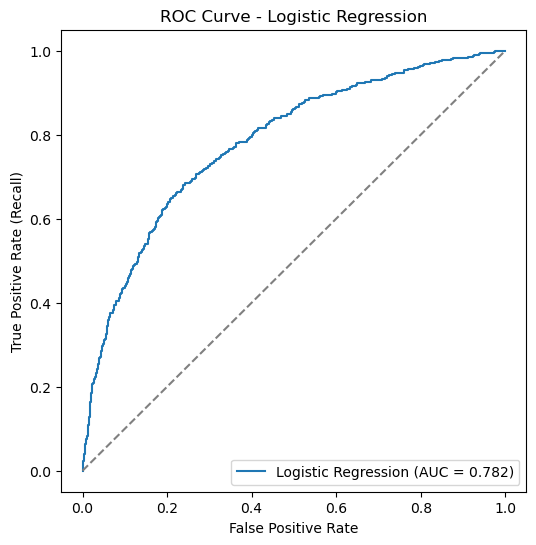

In [74]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# Predicted probabilities for class 1 (churn)
y_prob = logreg.predict_proba(X_test)[:,1]

# AUC score
auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="Logistic Regression (AUC = %.3f)" % auc)
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()


### What your ROC curve & AUC = 0.782 mean

Model is better than guessing

Random guessing = 0.5 (the gray line).

Your model = 0.782 → quite good, it can separate churners vs. non-churners most of the time.

It catches patterns of churn

Logistic Regression is able to detect who is likely to churn, but not perfectly.

It misses many churners (False Negatives = 1465).

Trade-off (Catch more churners vs. more mistakes)

If you lower the threshold (say predict churn if probability > 0.3 instead of > 0.5), the model will catch more churners.

But it will also wrongly label more loyal customers as churners.

Business must decide which mistake is costlier:

Missing a churner (they leave silently)

Or wrongly targeting a loyal customer (extra cost in retention campaigns).

In [75]:
# GB Confusion Matrix
model_GB = GradientBoostingClassifier(random_state=12345)
model_GB.fit(X_train, y_train)
y_pred = model_GB.predict(X_test)
conf_mat = confusion_matrix(y_pred,y_test)
conf_mat

array([[1516,  228],
       [  57,  199]])

In [76]:
print(classification_report(model_GB.predict(X_test,y_test))

              precision    recall  f1-score   support

           0       0.96      0.87      0.91      1744
           1       0.47      0.78      0.58       256

    accuracy                           0.86      2000
   macro avg       0.71      0.82      0.75      2000
weighted avg       0.90      0.86      0.87      2000



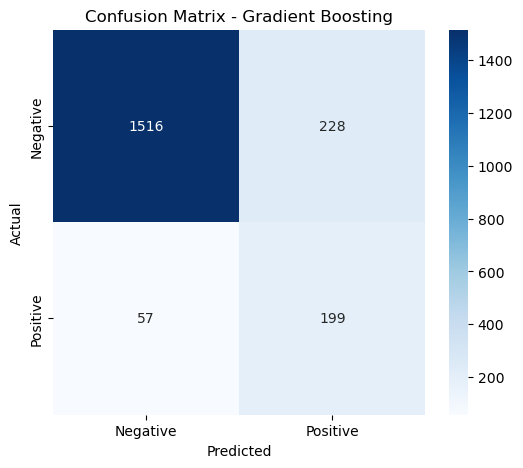

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = np.array([[1516, 228],
               [57, 199]])

labels = ["Negative", "Positive"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### Key Insights

Positive = Churn (customer will leave)

Negative = Not Churn (customer will stay)

What it means in churn prediction:

 1516 (TN): Model correctly said these customers will stay → and they actually stayed.
 228 (FP): Model said these customers will churn → but they actually stayed.

Business impact: you might waste retention offers (discounts, calls, free perks) on them unnecessarily.

 57 (FN): Model said these customers will stay → but they actually churned.

Business impact: you lose these customers without trying to save them.

 199 (TP): Model correctly said these customers will churn → and they did.

Business impact: you can target them with retention strategies.

Metrics in churn context:

Recall (77.7%) → Out of all customers who left, model catches ~78%.
 Good: most churners are detected.

Precision (46.6%) → Out of all customers predicted as churn, only ~47% really churn.
 Problem: more than half of your retention efforts are wasted on non-churners.

Accuracy (85.8%) → Looks high, but mostly because many customers do not churn.

Easy takeaway:

Model is good at finding churners, but not so good at being sure about them.

If saving churners is more important (e.g., churn is very costly), this model is helpful.

If retention campaigns are expensive, the low precision (lots of false alarms) could be a problem.

👉 In business terms:

Good for recall-focused strategy → e.g., if losing one customer costs much more than offering discounts to a few extra.

But needs improvement in precision if you want to reduce wasted retention costs.

AUC Score: 0.8777273397243591


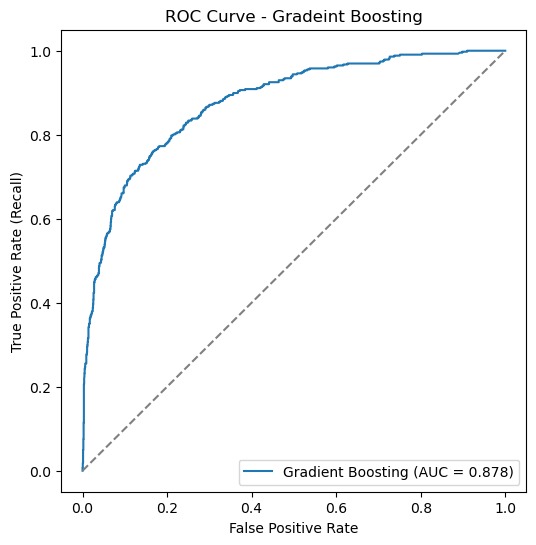

In [80]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# Predicted probabilities for class 1 (churn)
y_prob = model_GB.predict_proba(X_test)[:,1]

# AUC score
auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="Gradient Boosting (AUC = %.3f)" % auc)
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Gradeint Boosting")
plt.legend(loc="lower right")
plt.show()

#### Conclusion
Between the two models, **Gradient Boosting clearly outperforms Logistic Regression**. The ROC curve of Gradient Boosting consistently stays above that of Logistic Regression, and the AUC score of **0.878** is significantly higher than **0.782** from Logistic Regression. This indicates that Gradient Boosting is better at distinguishing between churn and non-churn customers, providing higher recall for the same level of false positives. Therefore, for churn prediction in this case, **Gradient Boosting is the preferred model** due to its stronger discriminatory power and overall predictive performance.
